# 1. Structural Auditory

Gran Canaria master built successfully for 2015-12-28 to 2024-12-30 (471 weeks).
Coverage limitations are source-driven, not merge errors:
- CAP available from 2018-06-18 onward.
- Heliyon/DAI available only up to March 2022.
Minor missingness remains in selected weather and air-quality variables.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import display

def section(t): 
    print("\n" + "="*80); print(t); print("="*80)

def session(title):
    section(f"SESSION: {title}")
    print("Problem -> Data -> QA -> Summaries -> EDA -> Conclusión -> Next")

def glance(df, name="df", n=3):
    section(f"GLANCE: {name}")
    print("shape:", df.shape)
    print("dups:", df.duplicated().sum())
    na = df.isna().sum()
    na = na[na>0].sort_values(ascending=False)
    print("missing cols:", len(na))
    if len(na): display(na.head(25))
    display(df.head(n))
    display(df.dtypes.to_frame("dtype"))

def checks(df, required=None, key=None, dt=None):
    section("QA CHECKS")
    ok = True
    
    if required:
        miss = [c for c in required if c not in df.columns]
        if miss:
            ok = False
            print("❌ missing columns:", miss)
        else:
            print("✅ required columns ok")

    if key:
        d = df.duplicated(subset=key).sum()
        if d:
            ok = False
            print(f"❌ duplicated key rows: {d} (key={key})")
        else:
            print(f"✅ unique key ok (key={key})")

    if dt:
        if dt not in df.columns:
            ok = False
            print(f"❌ datetime col not found: {dt}")
        elif not np.issubdtype(df[dt].dtype, np.datetime64):
            ok = False
            print(f"❌ {dt} is {df[dt].dtype} (expected datetime64)")
        else:
            print(f"✅ datetime ok: {dt}")

    print("\nRESULT:", "✅ PASS" if ok else "❌ FAIL")
    return ok

def num_summary(df):
    section("NUMERIC SUMMARY")
    cols = df.select_dtypes(include=[np.number]).columns
    display(df[cols].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).T.assign(
        missing=df[cols].isna().sum(),
        missing_pct=lambda x: x["missing"]/len(df)
    ).sort_values("missing_pct", ascending=False))

In [2]:
# Cargar Master GC

# --- find project root (folder that contains /data) ---
def find_project_root(start: Path) -> Path:
    p = start.resolve()
    for _ in range(10):
        if (p / "data").exists():
            return p
        p = p.parent
    raise FileNotFoundError("No encuentro la raíz del proyecto (no veo /data en padres).")

ROOT = find_project_root(Path.cwd())

FP = ROOT / "data" / "processed" / "gran_canaria" / "master" / "master_gcan_2015_2024.parquet"

print("ROOT:", ROOT)
print("FP:", FP)
assert FP.exists(), f"No existe: {FP}"

session("EDA core weekly Gran Canaria")

df = pd.read_parquet(FP)
df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")

glance(df, "eda_core_weekly_gcan")

checks(
    df,
    required=["week_start", "deaths_week"],
    key=["week_start"],
    dt="week_start"
)

num_summary(df)

ROOT: C:\dev\projects\heat_mortality_analysis
FP: C:\dev\projects\heat_mortality_analysis\data\processed\gran_canaria\master\master_gcan_2015_2024.parquet

SESSION: EDA core weekly Gran Canaria
Problem -> Data -> QA -> Summaries -> EDA -> Conclusión -> Next

GLANCE: eda_core_weekly_gcan
shape: (471, 36)
dups: 0
missing cols: 16


calima_level_week            146
calima_dai_flag              146
cap_dust_level_max_week      129
cap_dust_yellow_plus_week    129
cap_heat_yellow_plus_week    129
cap_heat_level_max_week      129
cap_coverage_week            129
SO2                           17
PM2.5                         11
O3                             6
pressure_hpa_mean              1
rh_min_pct_week                1
tmax_c_mean                    1
temp_c_mean                    1
tmin_c_mean                    1
humidity_mean                  1
dtype: int64

,week_start,year,island,island_code,deaths_week,temp_c_mean,tmax_c_mean,tmin_c_mean,humidity_mean,pressure_hpa_mean,...,O3,days_with_pm10,days_missing_pm10,cap_heat_level_max_week,cap_dust_level_max_week,cap_heat_yellow_plus_week,cap_dust_yellow_plus_week,cap_coverage_week,calima_dai_flag,calima_level_week
0,2015-12-28,2015,gran_canaria,gcan,133.0,19.500000,22.333333,16.666667,75.666667,1020.666667,...,69.333333,3,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
1,2016-01-04,2016,gran_canaria,gcan,126.0,19.400000,22.557143,16.242857,70.571429,1016.785714,...,64.142857,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
2,2016-01-11,2016,gran_canaria,gcan,127.0,20.528571,23.871429,17.214286,69.714286,1015.971429,...,54.857143,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0


,dtype
week_start,datetime64[ns]
year,int32
island,object
island_code,object
deaths_week,float64
temp_c_mean,float64
tmax_c_mean,float64
tmin_c_mean,float64
humidity_mean,float64
pressure_hpa_mean,float64



QA CHECKS
✅ required columns ok
✅ unique key ok (key=['week_start'])
✅ datetime ok: week_start

RESULT: ✅ PASS

NUMERIC SUMMARY


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing,missing_pct
calima_dai_flag,325.0,0.248357,1.222680,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.935844,4.390458,16.666667,146,0.309979
calima_level_week,325.0,0.286154,0.750283,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,3.000000,3.000000,146,0.309979
cap_heat_level_max_week,342.0,1.271930,0.653685,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,4.000000,4.000000,129,0.273885
cap_dust_yellow_plus_week,342.0,0.073099,0.260681,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,129,0.273885
cap_coverage_week,342.0,0.993317,0.045932,0.285714,0.857143,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,129,0.273885
cap_heat_yellow_plus_week,342.0,0.175439,0.380899,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,129,0.273885
cap_dust_level_max_week,342.0,1.073099,0.260681,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,129,0.273885
SO2,454.0,6.840319,4.008764,0.285714,1.000000,1.285714,3.857143,6.142857,9.000000,14.428571,19.125714,29.571429,17,0.036093
PM2.5,460.0,19.424591,16.232243,3.500000,5.285714,7.714286,12.421429,16.000000,20.714286,42.878571,84.630000,217.857143,11,0.023355
O3,465.0,70.470891,11.065228,35.000000,44.548571,52.457143,62.714286,69.714286,78.142857,89.371429,94.542857,107.857143,6,0.012739


### Conclusion 1:
El dataset no está roto.
Los nulos no apuntan a un merge mal hecho; apuntan a fuentes que no cubren todo el periodo.

## Crear tables QA y figures

In [3]:
# Define output routes: 
REPORT_TABLES = ROOT / "reports" / "tables" / "island" / "GC"
REPORT_FIGURES = ROOT / "reports" / "figures" / "island" / "GC"

REPORT_TABLES.mkdir(parents=True, exist_ok=True)
REPORT_FIGURES.mkdir(parents=True, exist_ok=True)

print("Tables ->", REPORT_TABLES)
print("Figures ->", REPORT_FIGURES)

Tables -> C:\dev\projects\heat_mortality_analysis\reports\tables\island\GC
Figures -> C:\dev\projects\heat_mortality_analysis\reports\figures\island\GC


In [4]:
qa = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_n": df.isna().sum(),
    "missing_pct": (df.isna().sum() / len(df)).round(4),
    "unique_n": df.nunique(dropna=True)
}).sort_values(["missing_pct", "missing_n"], ascending=False)

qa_path_csv = REPORT_TABLES / "qa_table_gcan.csv"
qa_path_xlsx = REPORT_TABLES / "qa_table_gcan.xlsx"

qa.to_csv(qa_path_csv)
qa.to_excel(qa_path_xlsx)

display(qa.head(20))
print("Saved:", qa_path_csv)
print("Saved:", qa_path_xlsx)

,dtype,missing_n,missing_pct,unique_n
calima_dai_flag,float64,146,0.3100,30
calima_level_week,float64,146,0.3100,4
cap_heat_level_max_week,float64,129,0.2739,4
cap_dust_level_max_week,float64,129,0.2739,2
cap_heat_yellow_plus_week,float64,129,0.2739,2
cap_dust_yellow_plus_week,float64,129,0.2739,2
cap_coverage_week,float64,129,0.2739,3
SO2,float64,17,0.0361,123
PM2.5,float64,11,0.0234,199
O3,float64,6,0.0127,242


Saved: C:\dev\projects\heat_mortality_analysis\reports\tables\island\GC\qa_table_gcan.csv
Saved: C:\dev\projects\heat_mortality_analysis\reports\tables\island\GC\qa_table_gcan.xlsx


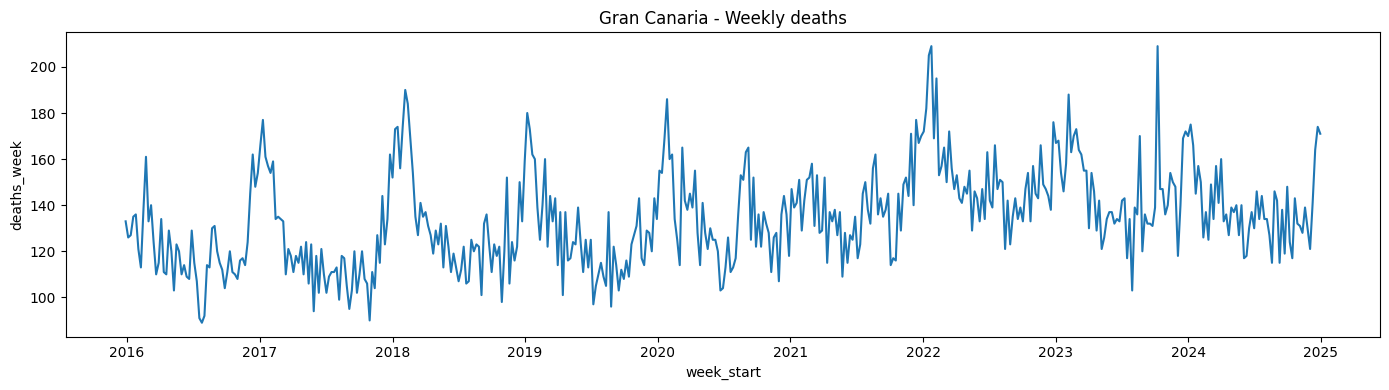

Saved: C:\dev\projects\heat_mortality_analysis\reports\figures\island\GC\ts_deaths_week_gcan.png


In [5]:
# Graphics weekly deaths
fig1 = REPORT_FIGURES / "ts_deaths_week_gcan.png"

plt.figure(figsize=(14, 4))
plt.plot(df["week_start"], df["deaths_week"])
plt.title("Gran Canaria - Weekly deaths")
plt.xlabel("week_start")
plt.ylabel("deaths_week")
plt.tight_layout()
plt.savefig(fig1, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig1)

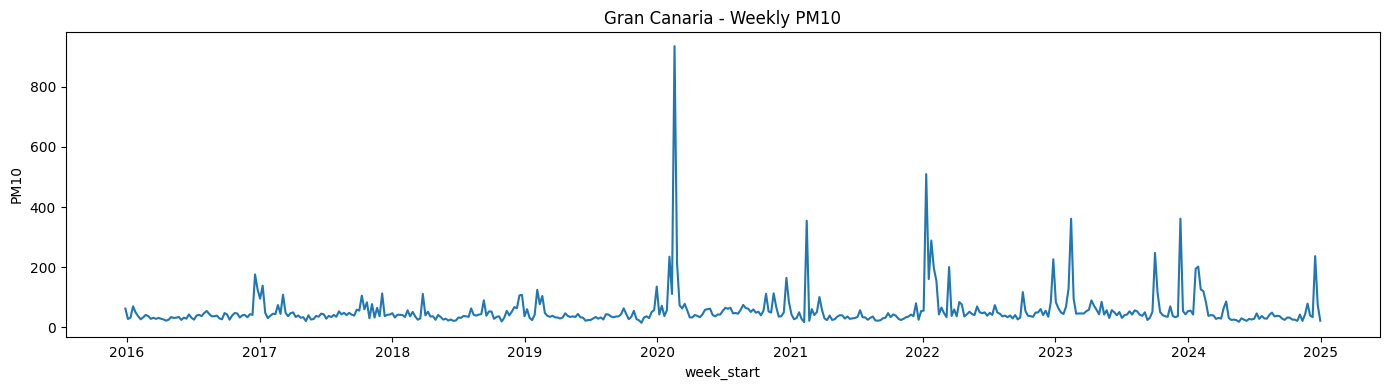

Saved: C:\dev\projects\heat_mortality_analysis\reports\figures\island\GC\ts_pm10_week_gcan.png


In [6]:
# Graphic pm10 weekly
fig2 = REPORT_FIGURES / "ts_pm10_week_gcan.png"

plt.figure(figsize=(14, 4))
plt.plot(df["week_start"], df["PM10"])
plt.title("Gran Canaria - Weekly PM10")
plt.xlabel("week_start")
plt.ylabel("PM10")
plt.tight_layout()
plt.savefig(fig2, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig2)

# EDA Absolute Temperature

In [7]:
temp_vars = ["temp_c_mean", "tmax_c_mean", "tmin_c_mean", "deaths_week"]
df[temp_vars].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
temp_c_mean,470.0,21.781848,2.643902,15.642857,17.016286,17.857143,19.503571,21.759524,24.064286,25.772857,27.335214,28.828571
tmax_c_mean,470.0,24.859832,2.754151,18.528571,19.950286,20.725714,22.575000,24.835714,26.967857,29.300000,30.933714,32.883333
tmin_c_mean,470.0,18.705002,2.601231,12.742857,13.842857,14.838214,16.407143,18.546429,21.100000,22.562143,23.758000,24.928571
deaths_week,471.0,134.309979,20.705675,89.000000,94.700000,105.000000,119.000000,133.000000,147.000000,171.000000,188.600000,209.000000


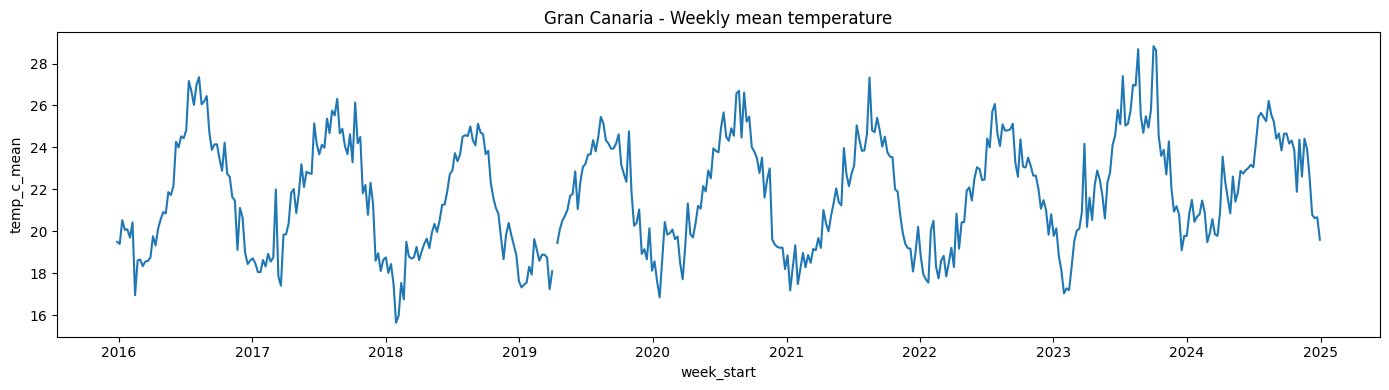

In [8]:
plt.figure(figsize=(14,4))
plt.plot(df["week_start"], df["temp_c_mean"])
plt.title("Gran Canaria - Weekly mean temperature")
plt.xlabel("week_start")
plt.ylabel("temp_c_mean")
plt.tight_layout()
plt.show()

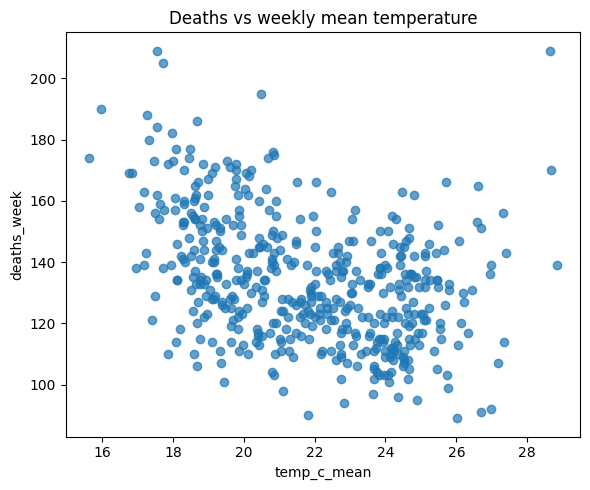

In [9]:
plt.figure(figsize=(6,5))
plt.scatter(df["temp_c_mean"], df["deaths_week"], alpha=0.7)
plt.title("Deaths vs weekly mean temperature")
plt.xlabel("temp_c_mean")
plt.ylabel("deaths_week")
plt.tight_layout()
plt.show()

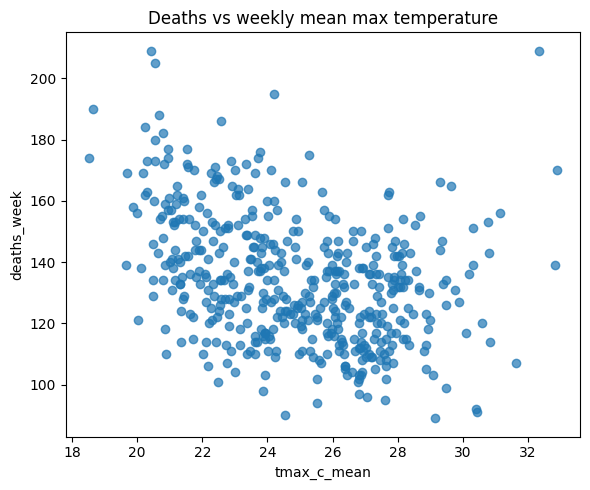

In [10]:
plt.figure(figsize=(6,5))
plt.scatter(df["tmax_c_mean"], df["deaths_week"], alpha=0.7)
plt.title("Deaths vs weekly mean max temperature")
plt.xlabel("tmax_c_mean")
plt.ylabel("deaths_week")
plt.tight_layout()
plt.show()

In [11]:
#Correlations
df[["deaths_week", "temp_c_mean", "tmax_c_mean", "tmin_c_mean"]].corr(numeric_only=True)

,deaths_week,temp_c_mean,tmax_c_mean,tmin_c_mean
deaths_week,1.000000,-0.392819,-0.365004,-0.412077
temp_c_mean,-0.392819,1.000000,0.988273,0.986825
tmax_c_mean,-0.365004,0.988273,1.000000,0.950599
tmin_c_mean,-0.412077,0.986825,0.950599,1.000000


In [12]:
# Group temperatures in bins
tmp = df[["temp_c_mean", "deaths_week"]].dropna().copy()
tmp["temp_bin"] = pd.qcut(tmp["temp_c_mean"], q=5, duplicates="drop")

temp_bin_summary = (
    tmp.groupby("temp_bin", observed=False)
       .agg(
           weeks=("deaths_week", "size"),
           temp_mean=("temp_c_mean", "mean"),
           deaths_mean=("deaths_week", "mean"),
           deaths_median=("deaths_week", "median")
       )
       .reset_index()
)

temp_bin_summary

,temp_bin,weeks,temp_mean,deaths_mean,deaths_median
0,"(15.642000000000001, 19.143]",94,18.240046,150.106383,152.0
1,"(19.143, 20.786]",95,19.935524,139.200000,137.0
2,"(20.786, 22.734]",93,21.723927,130.430108,127.0
3,"(22.734, 24.389]",94,23.612214,122.425532,120.0
4,"(24.389, 28.829]",94,25.416555,129.265957,131.0


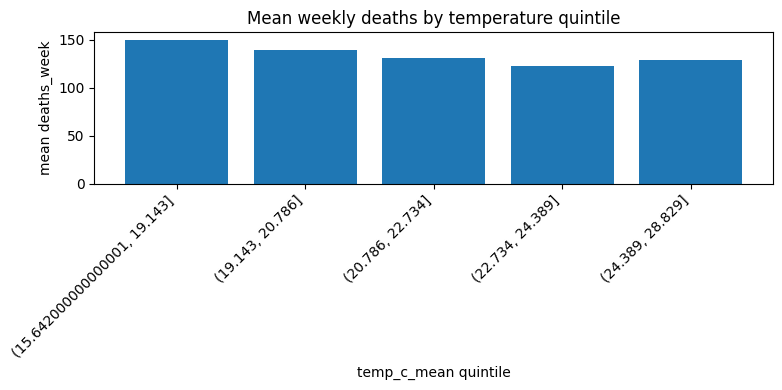

In [13]:
#Bar plot mean death by thermic quintale
plt.figure(figsize=(8,4))
plt.bar(range(len(temp_bin_summary)), temp_bin_summary["deaths_mean"])
plt.xticks(range(len(temp_bin_summary)), temp_bin_summary["temp_bin"].astype(str), rotation=45, ha="right")
plt.title("Mean weekly deaths by temperature quintile")
plt.xlabel("temp_c_mean quintile")
plt.ylabel("mean deaths_week")
plt.tight_layout()
plt.show()

En Gran Canaria, la mortalidad media semanal disminuye a medida que aumenta la temperatura media semanal a través de los primeros cuatro quintiles, con un leve repunte en el quintil más cálido. Esto sugiere una relación no estrictamente lineal y probablemente influida por estacionalidad.

## Thermic Anomaly

In [14]:
# Weekly climatology and anomaly
temp_df = df.copy()
temp_df["weekofyear"] = temp_df["week_start"].dt.isocalendar().week.astype(int)

clim_temp = (
    temp_df.groupby("weekofyear", observed=False)["temp_c_mean"]
           .mean()
           .rename("temp_c_clim")
           .reset_index()
)

temp_df = temp_df.merge(clim_temp, on="weekofyear", how="left")
temp_df["temp_c_anom"] = temp_df["temp_c_mean"] - temp_df["temp_c_clim"]  # This is the central idea.

#quick check
temp_df[["week_start", "temp_c_mean", "temp_c_clim", "temp_c_anom"]].head(10)

,week_start,temp_c_mean,temp_c_clim,temp_c_anom
0,2015-12-28,19.500000,18.850000,0.650000
1,2016-01-04,19.400000,18.950476,0.449524
2,2016-01-11,20.528571,18.786772,1.741799
3,2016-01-18,20.071429,18.661640,1.409788
4,2016-01-25,20.100000,18.395238,1.704762
5,2016-02-01,19.700000,18.473545,1.226455
6,2016-02-08,20.428571,18.885450,1.543122
7,2016-02-15,16.957143,18.763492,-1.806349
8,2016-02-22,18.614286,18.690741,-0.076455
9,2016-02-29,18.657143,19.120635,-0.463492


In [15]:
temp_df[["temp_c_mean", "temp_c_clim", "temp_c_anom"]].describe()

,temp_c_mean,temp_c_clim,temp_c_anom
count,470.000000,471.000000,4.700000e+02
mean,21.781848,21.779946,6.047172e-17
std,2.643902,2.405243,1.092885e+00
min,15.642857,18.395238,-2.899735e+00
25%,19.503571,19.366667,-7.857143e-01
50%,21.759524,21.446561,-1.342593e-01
75%,24.064286,24.205291,6.250000e-01
max,28.828571,25.900952,4.652751e+00


In [16]:
#deaths correlations
temp_df = df.copy()
temp_df["weekofyear"] = temp_df["week_start"].dt.isocalendar().week.astype(int)

for var in ["temp_c_mean", "tmax_c_mean", "tmin_c_mean"]:
    clim = (
        temp_df.groupby("weekofyear", observed=False)[var]
               .mean()
               .rename(f"{var}_clim")
               .reset_index()
    )
    temp_df = temp_df.merge(clim, on="weekofyear", how="left")
    temp_df[f"{var}_anom"] = temp_df[var] - temp_df[f"{var}_clim"]

temp_df[[
    "deaths_week",
    "temp_c_mean", "temp_c_mean_anom",
    "tmax_c_mean", "tmax_c_mean_anom",
    "tmin_c_mean", "tmin_c_mean_anom"
]].corr(numeric_only=True)



,deaths_week,temp_c_mean,temp_c_mean_anom,tmax_c_mean,tmax_c_mean_anom,tmin_c_mean,tmin_c_mean_anom
deaths_week,1.000000,-0.392819,0.064339,-0.365004,0.087637,-0.412077,0.026091
temp_c_mean,-0.392819,1.000000,0.413361,0.988273,0.398837,0.986825,0.386724
temp_c_mean_anom,0.064339,0.413361,1.000000,0.460684,0.964864,0.352113,0.935560
tmax_c_mean,-0.365004,0.988273,0.460684,1.000000,0.477461,0.950599,0.386805
tmax_c_mean_anom,0.087637,0.398837,0.964864,0.477461,1.000000,0.304905,0.810130
tmin_c_mean,-0.412077,0.986825,0.352113,0.950599,0.304905,1.000000,0.376366
tmin_c_mean_anom,0.026091,0.386724,0.935560,0.386805,0.810130,0.376366,1.000000


En Gran Canaria, la asociación negativa observada entre mortalidad semanal y temperatura absoluta parece estar dominada por estacionalidad. Al usar anomalías térmicas semanales, la correlación con la mortalidad se reduce casi a cero.

#### temperatura absoluta sirve para mostrar la estructura estacional general

#### anomalía térmica sirve para mostrar que esa relación bruta no se sostiene como efecto claro fuera de la estacionalidad

In [17]:
# Define extems p90/p95
heat_df = df.copy()

# percentiles sobre semanas con dato
p90_tmax = heat_df["tmax_c_mean"].quantile(0.90)
p95_tmax = heat_df["tmax_c_mean"].quantile(0.95)

p90_temp = heat_df["temp_c_mean"].quantile(0.90)
p95_temp = heat_df["temp_c_mean"].quantile(0.95)

heat_df["tmax_p90"] = (heat_df["tmax_c_mean"] >= p90_tmax).astype(int)
heat_df["tmax_p95"] = (heat_df["tmax_c_mean"] >= p95_tmax).astype(int)

heat_df["temp_p90"] = (heat_df["temp_c_mean"] >= p90_temp).astype(int)
heat_df["temp_p95"] = (heat_df["temp_c_mean"] >= p95_temp).astype(int)

print("tmax_c_mean p90:", round(p90_tmax, 2))
print("tmax_c_mean p95:", round(p95_tmax, 2))
print("temp_c_mean p90:", round(p90_temp, 2))
print("temp_c_mean p95:", round(p95_temp, 2))

heat_df[["tmax_p90", "tmax_p95", "temp_p90", "temp_p95"]].sum()

tmax_c_mean p90: 28.19
tmax_c_mean p95: 29.3
temp_c_mean p90: 25.12
temp_c_mean p95: 25.77


tmax_p90    48
tmax_p95    25
temp_p90    47
temp_p95    24
dtype: int64

In [18]:
# Create lags for deaths
heat_df = heat_df.sort_values("week_start").reset_index(drop=True)

heat_df["deaths_lag0"] = heat_df["deaths_week"]
heat_df["deaths_lag1"] = heat_df["deaths_week"].shift(-1)

In [19]:
# Compare simple average
def mean_compare(data, flag, outcome):
    tmp = data[[flag, outcome]].dropna()
    out = (
        tmp.groupby(flag, observed=False)[outcome]
           .agg(["count", "mean", "median", "std"])
           .rename(index={0: "non_extreme", 1: "extreme"})
    )
    return out

mean_compare(heat_df, "tmax_p90", "deaths_lag0")


,count,mean,median,std
tmax_p90,,,,
non_extreme,423,134.699764,133.0,20.465488
extreme,48,130.875000,131.0,22.654317


In [20]:
mean_compare(heat_df, "tmax_p90", "deaths_lag1")

,count,mean,median,std
tmax_p90,,,,
non_extreme,422,134.770142,133.0,20.553430
extreme,48,130.291667,130.5,22.018327


In [21]:
mean_compare(heat_df, "tmax_p95", "deaths_lag0")

,count,mean,median,std
tmax_p95,,,,
non_extreme,446,134.195067,133.0,20.362448
extreme,25,136.360000,136.0,26.520244


In [22]:
mean_compare(heat_df, "tmax_p95", "deaths_lag1")

,count,mean,median,std
tmax_p95,,,,
non_extreme,445,134.438202,133.0,20.339990
extreme,25,132.080000,125.0,27.139946


In [23]:
# Compare with average temperature
mean_compare(heat_df, "temp_p90", "deaths_lag0")


,count,mean,median,std
temp_p90,,,,
non_extreme,424,134.629717,133.0,20.503524
extreme,47,131.425532,132.0,22.476794


In [24]:
mean_compare(heat_df, "temp_p90", "deaths_lag1")


,count,mean,median,std
temp_p90,,,,
non_extreme,423,134.803783,133.0,20.491861
extreme,47,129.893617,132.0,22.493704


In [25]:
mean_compare(heat_df, "temp_p95", "deaths_lag0")

,count,mean,median,std
temp_p95,,,,
non_extreme,447,134.355705,133.0,20.333125
extreme,24,133.458333,132.0,27.258791


In [26]:
mean_compare(heat_df, "temp_p95", "deaths_lag1")

,count,mean,median,std
temp_p95,,,,
non_extreme,446,134.500000,133.0,20.273606
extreme,24,130.833333,127.5,28.199085


In [27]:
def diff_means(data, flag, outcome):
    tmp = data[[flag, outcome]].dropna()
    means = tmp.groupby(flag, observed=False)[outcome].mean()
    return means.get(1, np.nan) - means.get(0, np.nan)

for flag in ["tmax_p90", "tmax_p95", "temp_p90", "temp_p95"]:
    for outcome in ["deaths_lag0", "deaths_lag1"]:
        print(flag, outcome, "diff =", round(diff_means(heat_df, flag, outcome), 2))

tmax_p90 deaths_lag0 diff = -3.82
tmax_p90 deaths_lag1 diff = -4.48
tmax_p95 deaths_lag0 diff = 2.16
tmax_p95 deaths_lag1 diff = -2.36
temp_p90 deaths_lag0 diff = -3.2
temp_p90 deaths_lag1 diff = -4.91
temp_p95 deaths_lag0 diff = -0.9
temp_p95 deaths_lag1 diff = -3.67


In [28]:
from scipy.stats import ttest_ind

def quick_ttest(data, flag, outcome):
    tmp = data[[flag, outcome]].dropna()
    a = tmp.loc[tmp[flag] == 1, outcome]
    b = tmp.loc[tmp[flag] == 0, outcome]
    stat, p = ttest_ind(a, b, equal_var=False, nan_policy="omit")
    return {
        "n_extreme": len(a),
        "n_non_extreme": len(b),
        "mean_extreme": a.mean(),
        "mean_non_extreme": b.mean(),
        "diff": a.mean() - b.mean(),
        "p_value": p,
    }

for flag in ["tmax_p90", "tmax_p95", "temp_p90", "temp_p95"]:
    for outcome in ["deaths_lag0", "deaths_lag1"]:
        print(flag, outcome, quick_ttest(heat_df, flag, outcome))

tmax_p90 deaths_lag0 {'n_extreme': 48, 'n_non_extreme': 423, 'mean_extreme': np.float64(130.875), 'mean_non_extreme': np.float64(134.69976359338062), 'diff': np.float64(-3.8247635933806237), 'p_value': np.float64(0.2678991779894702)}
tmax_p90 deaths_lag1 {'n_extreme': 48, 'n_non_extreme': 422, 'mean_extreme': np.float64(130.29166666666666), 'mean_non_extreme': np.float64(134.77014218009478), 'diff': np.float64(-4.478475513428123), 'p_value': np.float64(0.1842543538206329)}
tmax_p95 deaths_lag0 {'n_extreme': 25, 'n_non_extreme': 446, 'mean_extreme': np.float64(136.36), 'mean_non_extreme': np.float64(134.195067264574), 'diff': np.float64(2.164932735426021), 'p_value': np.float64(0.6913210888922148)}
tmax_p95 deaths_lag1 {'n_extreme': 25, 'n_non_extreme': 445, 'mean_extreme': np.float64(132.08), 'mean_non_extreme': np.float64(134.43820224719101), 'diff': np.float64(-2.3582022471910022), 'p_value': np.float64(0.6724146080567293)}
temp_p90 deaths_lag0 {'n_extreme': 47, 'n_non_extreme': 424,

En Gran Canaria, los extremos térmicos semanales definidos por percentiles p90/p95 de temperatura media o máxima no muestran una asociación clara con incrementos de mortalidad semanal en lag 0 o lag 1. Las diferencias de medias son pequeñas o inconsistentes en signo, y los contrastes de Welch no resultan significativos.

In [29]:
# save table p90/p95 and deaths
from pathlib import Path
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind

# --- output dir ---
OUT_DIR = ROOT / "reports" / "tables" / "island" / "GC"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- working copy ---
heat_df = df.copy().sort_values("week_start").reset_index(drop=True)

# lags
heat_df["deaths_lag0"] = heat_df["deaths_week"]
heat_df["deaths_lag1"] = heat_df["deaths_week"].shift(-1)

# percentiles
p90_tmax = heat_df["tmax_c_mean"].quantile(0.90)
p95_tmax = heat_df["tmax_c_mean"].quantile(0.95)
p90_temp = heat_df["temp_c_mean"].quantile(0.90)
p95_temp = heat_df["temp_c_mean"].quantile(0.95)

# flags
heat_df["tmax_p90"] = (heat_df["tmax_c_mean"] >= p90_tmax).astype(int)
heat_df["tmax_p95"] = (heat_df["tmax_c_mean"] >= p95_tmax).astype(int)
heat_df["temp_p90"] = (heat_df["temp_c_mean"] >= p90_temp).astype(int)
heat_df["temp_p95"] = (heat_df["temp_c_mean"] >= p95_temp).astype(int)

threshold_map = {
    "tmax_p90": ("tmax_c_mean", 0.90, p90_tmax),
    "tmax_p95": ("tmax_c_mean", 0.95, p95_tmax),
    "temp_p90": ("temp_c_mean", 0.90, p90_temp),
    "temp_p95": ("temp_c_mean", 0.95, p95_temp),
}

def extreme_summary(data, flag, outcome):
    tmp = data[[flag, outcome]].dropna().copy()
    a = tmp.loc[tmp[flag] == 1, outcome]
    b = tmp.loc[tmp[flag] == 0, outcome]

    stat, p = ttest_ind(a, b, equal_var=False, nan_policy="omit")

    return {
        "n_extreme": len(a),
        "n_non_extreme": len(b),
        "mean_extreme": a.mean(),
        "mean_non_extreme": b.mean(),
        "diff_extreme_minus_nonextreme": a.mean() - b.mean(),
        "median_extreme": a.median(),
        "median_non_extreme": b.median(),
        "p_value_welch": p,
    }

rows = []
for flag in ["tmax_p90", "tmax_p95", "temp_p90", "temp_p95"]:
    source_var, percentile, threshold_value = threshold_map[flag]
    for lag in ["deaths_lag0", "deaths_lag1"]:
        out = extreme_summary(heat_df, flag, lag)
        out["extreme_flag"] = flag
        out["source_var"] = source_var
        out["percentile"] = percentile
        out["threshold_value"] = threshold_value
        out["death_lag"] = lag
        rows.append(out)

extreme_table = pd.DataFrame(rows)[[
    "extreme_flag",
    "source_var",
    "percentile",
    "threshold_value",
    "death_lag",
    "n_extreme",
    "n_non_extreme",
    "mean_extreme",
    "mean_non_extreme",
    "diff_extreme_minus_nonextreme",
    "median_extreme",
    "median_non_extreme",
    "p_value_welch",
]].sort_values(["source_var", "percentile", "death_lag"]).reset_index(drop=True)

# round for reporting
extreme_table_report = extreme_table.copy()
for c in ["threshold_value", "mean_extreme", "mean_non_extreme",
          "diff_extreme_minus_nonextreme", "median_extreme",
          "median_non_extreme", "p_value_welch"]:
    extreme_table_report[c] = extreme_table_report[c].round(3)

# versión más presentable para informe
report_table = extreme_table.copy()

report_table["metric"] = report_table["source_var"].map({
    "tmax_c_mean": "Weekly mean max temperature",
    "temp_c_mean": "Weekly mean temperature",
})

report_table["percentile_label"] = report_table["percentile"].map({
    0.90: "p90",
    0.95: "p95",
})

report_table["lag_label"] = report_table["death_lag"].map({
    "deaths_lag0": "lag0",
    "deaths_lag1": "lag1",
})

report_table = report_table[[
    "metric",
    "percentile_label",
    "threshold_value",
    "lag_label",
    "n_extreme",
    "n_non_extreme",
    "mean_extreme",
    "mean_non_extreme",
    "diff_extreme_minus_nonextreme",
    "p_value_welch",
]].rename(columns={
    "metric": "temperature_metric",
    "percentile_label": "extreme_definition",
    "threshold_value": "threshold",
    "lag_label": "death_lag",
    "n_extreme": "weeks_extreme",
    "n_non_extreme": "weeks_non_extreme",
    "mean_extreme": "mean_deaths_extreme",
    "mean_non_extreme": "mean_deaths_non_extreme",
    "diff_extreme_minus_nonextreme": "diff_deaths",
    "p_value_welch": "p_value",
}).sort_values(["temperature_metric", "extreme_definition", "death_lag"]).reset_index(drop=True)

for c in ["threshold", "mean_deaths_extreme", "mean_deaths_non_extreme", "diff_deaths", "p_value"]:
    report_table[c] = report_table[c].round(3)

csv_fp2 = OUT_DIR / "temperature_extremes_report_ready_gcan.csv"
xlsx_fp2 = OUT_DIR / "temperature_extremes_report_ready_gcan.xlsx"

report_table.to_csv(csv_fp2, index=False)


display(report_table)
print("Saved:", csv_fp2)

,temperature_metric,extreme_definition,threshold,death_lag,weeks_extreme,weeks_non_extreme,mean_deaths_extreme,mean_deaths_non_extreme,diff_deaths,p_value
0,Weekly mean max temperature,p90,28.186,lag0,48,423,130.875,134.700,-3.825,0.268
1,Weekly mean max temperature,p90,28.186,lag1,48,422,130.292,134.770,-4.478,0.184
2,Weekly mean max temperature,p95,29.300,lag0,25,446,136.360,134.195,2.165,0.691
3,Weekly mean max temperature,p95,29.300,lag1,25,445,132.080,134.438,-2.358,0.672
4,Weekly mean temperature,p90,25.116,lag0,47,424,131.426,134.630,-3.204,0.354
5,Weekly mean temperature,p90,25.116,lag1,47,423,129.894,134.804,-4.910,0.158
6,Weekly mean temperature,p95,25.773,lag0,24,447,133.458,134.356,-0.897,0.875
7,Weekly mean temperature,p95,25.773,lag1,24,446,130.833,134.500,-3.667,0.536


Saved: C:\dev\projects\heat_mortality_analysis\reports\tables\island\GC\temperature_extremes_report_ready_gcan.csv


# EDA GC - Calima, PM/ visibilidad.

In [30]:
# Dataset calima GC -> "C:\dev\projects\heat_mortality_analysis\data\processed\gran_canaria\calima\calima_proxy_weekly_gcan_2015_2024_v2.parquet"
# QA Dataset calima
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# --- find project root (folder that contains /data) ---
def find_project_root(start: Path) -> Path:
    p = start.resolve()
    for _ in range(10):
        if (p / "data").exists():
            return p
        p = p.parent
    raise FileNotFoundError("No encuentro la raíz del proyecto (no veo /data en padres).")

ROOT = find_project_root(Path.cwd())

CALIMA_FP = ROOT / "data" / "processed" / "gran_canaria" / "calima" / "calima_proxy_weekly_gcan_2015_2024_v2.parquet"
assert CALIMA_FP.exists(), f"No existe: {CALIMA_FP}"

cal_df = pd.read_parquet(CALIMA_FP)
cal_df["week_start"] = pd.to_datetime(cal_df["week_start"], errors="coerce")

print("shape:", cal_df.shape)
print("range:", cal_df["week_start"].min(), "->", cal_df["week_start"].max())
print("dup weeks:", cal_df["week_start"].duplicated().sum())
print("nulls:\n", cal_df[["week_start", "calima_proxy_score_v2", "calima_proxy_level_v2", "deaths_week"]].isna().sum())

display(cal_df.head())
display(cal_df["calima_proxy_level_v2"].value_counts(dropna=False))
# Segmentation by levels

shape: (471, 17)
range: 2015-12-28 00:00:00 -> 2024-12-30 00:00:00
dup weeks: 0
nulls:
 week_start               0
calima_proxy_score_v2    0
calima_proxy_level_v2    0
deaths_week              0
dtype: int64


,week_start,deaths_week,PM10,PM2.5,humidity_mean,pressure_hpa_mean,low_vis_any_week,cap_dust_yellow_plus_week,cap_dust_level_max_week,calima_dai_flag,pm10_p90_flag,pm10_p95_flag,hum_low_flag,low_vis_flag,pressure_high_flag,calima_proxy_score_v2,calima_proxy_level_v2
0,2015-12-28,133.0,62.666667,48.666667,75.666667,1020.666667,0,NaN,NaN,0.0,0,0,0,0,1,0.5,no_calima
1,2016-01-04,126.0,28.142857,17.285714,70.571429,1016.785714,0,NaN,NaN,0.0,0,0,0,0,1,0.5,no_calima
2,2016-01-11,127.0,32.428571,18.428571,69.714286,1015.971429,0,NaN,NaN,0.0,0,0,0,0,1,0.5,no_calima
3,2016-01-18,135.0,70.285714,25.000000,69.000000,1018.571429,0,NaN,NaN,0.0,0,0,0,0,1,0.5,no_calima
4,2016-01-25,136.0,50.285714,24.714286,60.571429,1023.285714,1,NaN,NaN,0.0,0,0,1,1,1,2.5,probable


calima_proxy_level_v2
possible     279
probable      79
no_calima     76
intense       37
Name: count, dtype: int64

In [31]:
# Proxi deaths/calima
cal_df[["deaths_week", "calima_proxy_score_v2"]].corr(numeric_only=True)

,deaths_week,calima_proxy_score_v2
deaths_week,1.000000,0.237257
calima_proxy_score_v2,0.237257,1.000000


In [32]:
cal_df[[
    "deaths_week",
    "calima_proxy_score_v2",
    "PM10",
    "low_vis_any_week",
    "humidity_mean",
    "pressure_hpa_mean"
]].corr(numeric_only=True)

,deaths_week,calima_proxy_score_v2,PM10,low_vis_any_week,humidity_mean,pressure_hpa_mean
deaths_week,1.000000,0.237257,0.252186,-0.131146,-0.169313,0.284462
calima_proxy_score_v2,0.237257,1.000000,0.599202,0.511281,-0.609028,0.375002
PM10,0.252186,0.599202,1.000000,0.135076,-0.312471,0.179486
low_vis_any_week,-0.131146,0.511281,0.135076,1.000000,-0.115026,-0.026601
humidity_mean,-0.169313,-0.609028,-0.312471,-0.115026,1.000000,-0.153609
pressure_hpa_mean,0.284462,0.375002,0.179486,-0.026601,-0.153609,1.000000


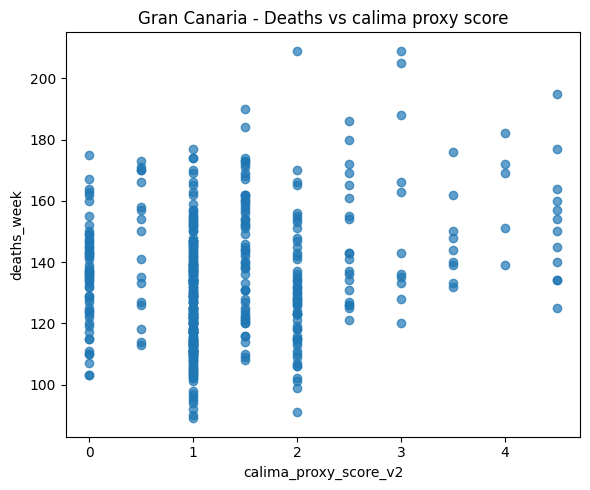

In [33]:
plt.figure(figsize=(6,5))
plt.scatter(cal_df["calima_proxy_score_v2"], cal_df["deaths_week"], alpha=0.7)
plt.title("Gran Canaria - Deaths vs calima proxy score")
plt.xlabel("calima_proxy_score_v2")
plt.ylabel("deaths_week")
plt.tight_layout()
plt.show()

In [34]:
score_summary = (
    cal_df.groupby("calima_proxy_score_v2", observed=False)
          .agg(
              weeks=("deaths_week", "size"),
              deaths_mean=("deaths_week", "mean"),
              deaths_median=("deaths_week", "median"),
              deaths_std=("deaths_week", "std")
          )
          .reset_index()
          .sort_values("calima_proxy_score_v2")
)

score_summary

,calima_proxy_score_v2,weeks,deaths_mean,deaths_median,deaths_std
0,0.0,59,135.830508,136.0,16.199353
1,0.5,17,145.647059,150.0,21.245415
2,1.0,219,127.123288,125.0,17.558248
3,1.5,60,144.166667,144.0,20.348795
4,2.0,59,129.661017,128.0,20.267700
5,2.5,20,146.600000,142.0,19.874342
6,3.0,11,156.909091,143.0,31.611563
7,3.5,9,147.111111,144.0,14.225369
8,4.0,5,162.600000,169.0,17.300289
9,4.5,12,152.916667,152.0,19.713670


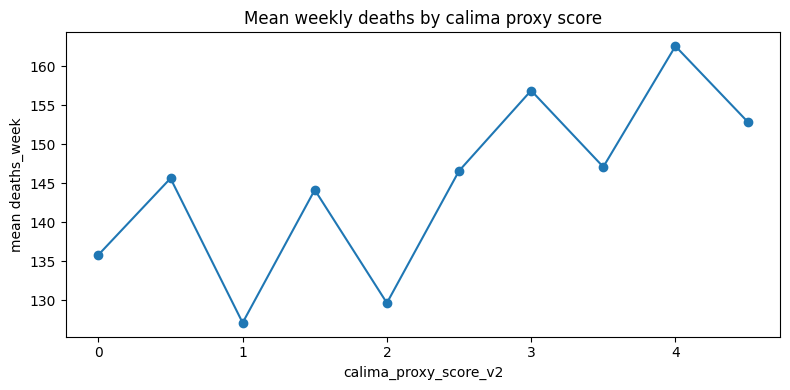

In [35]:
plt.figure(figsize=(8,4))
plt.plot(score_summary["calima_proxy_score_v2"], score_summary["deaths_mean"], marker="o")
plt.title("Mean weekly deaths by calima proxy score")
plt.xlabel("calima_proxy_score_v2")
plt.ylabel("mean deaths_week")
plt.tight_layout()
plt.show()

In [36]:
level_order = ["no_calima", "possible", "probable", "intense"]

level_summary = (
    cal_df.groupby("calima_proxy_level_v2", observed=False)
          .agg(
              weeks=("deaths_week", "size"),
              deaths_mean=("deaths_week", "mean"),
              deaths_median=("deaths_week", "median"),
              deaths_std=("deaths_week", "std"),
              score_mean=("calima_proxy_score_v2", "mean")
          )
          .reset_index()
)

level_summary["calima_proxy_level_v2"] = pd.Categorical(
    level_summary["calima_proxy_level_v2"],
    categories=level_order,
    ordered=True
)

level_summary = level_summary.sort_values("calima_proxy_level_v2")
level_summary

,calima_proxy_level_v2,weeks,deaths_mean,deaths_median,deaths_std,score_mean
1,no_calima,76,138.026316,137.0,17.781619,0.111842
2,possible,279,130.788530,129.0,19.463905,1.107527
3,probable,79,133.949367,130.0,21.368500,2.126582
0,intense,37,154.000000,150.0,22.353225,3.743243


En Gran Canaria, el calima proxy score muestra una correlación positiva moderada con la mortalidad semanal (r≈0.24), superior a la observada para las anomalías térmicas. La segmentación por niveles no sugiere un gradiente perfectamente monotónico, pero las semanas clasificadas como intense presentan una mortalidad media claramente más alta que el resto, lo que apunta a que el proxy puede ser más útil para identificar episodios intensos que como escala lineal continua.
### Siguiente paso:
 comparar intense vs no intense, en lag 0 y lag 1

In [37]:
cal_lag_df = cal_df.copy().sort_values("week_start").reset_index(drop=True)

cal_lag_df["intense_flag"] = (cal_lag_df["calima_proxy_level_v2"] == "intense").astype(int)

cal_lag_df["deaths_lag0"] = cal_lag_df["deaths_week"]
cal_lag_df["deaths_lag1"] = cal_lag_df["deaths_week"].shift(-1)

cal_lag_df[["week_start", "calima_proxy_level_v2", "intense_flag", "deaths_lag0", "deaths_lag1"]].head()

,week_start,calima_proxy_level_v2,intense_flag,deaths_lag0,deaths_lag1
0,2015-12-28,no_calima,0,133.0,126.0
1,2016-01-04,no_calima,0,126.0,127.0
2,2016-01-11,no_calima,0,127.0,135.0
3,2016-01-18,no_calima,0,135.0,136.0
4,2016-01-25,probable,0,136.0,121.0


In [38]:
def mean_compare(data, flag, outcome):
    tmp = data[[flag, outcome]].dropna()
    out = (
        tmp.groupby(flag, observed=False)[outcome]
           .agg(["count", "mean", "median", "std"])
           .rename(index={0: "non_intense", 1: "intense"})
    )
    return out

mean_compare(cal_lag_df, "intense_flag", "deaths_lag0")

,count,mean,median,std
intense_flag,,,,
non_intense,434,132.631336,131.0,19.694257
intense,37,154.000000,150.0,22.353225


In [39]:
mean_compare(cal_lag_df, "intense_flag", "deaths_lag1")

,count,mean,median,std
intense_flag,,,,
non_intense,433,132.757506,132.0,19.408590
intense,37,152.513514,155.0,26.595344


In [40]:
# Welch t-test
from scipy.stats import ttest_ind

def quick_ttest(data, flag, outcome):
    tmp = data[[flag, outcome]].dropna()
    a = tmp.loc[tmp[flag] == 1, outcome]
    b = tmp.loc[tmp[flag] == 0, outcome]
    stat, p = ttest_ind(a, b, equal_var=False, nan_policy="omit")
    return {
        "n_intense": len(a),
        "n_non_intense": len(b),
        "mean_intense": a.mean(),
        "mean_non_intense": b.mean(),
        "diff_intense_minus_non_intense": a.mean() - b.mean(),
        "p_value": p,
    }

print("lag0:", quick_ttest(cal_lag_df, "intense_flag", "deaths_lag0"))
print("lag1:", quick_ttest(cal_lag_df, "intense_flag", "deaths_lag1"))

lag0: {'n_intense': 37, 'n_non_intense': 434, 'mean_intense': np.float64(154.0), 'mean_non_intense': np.float64(132.63133640552996), 'diff_intense_minus_non_intense': np.float64(21.368663594470036), 'p_value': np.float64(1.454623049222325e-06)}
lag1: {'n_intense': 37, 'n_non_intense': 433, 'mean_intense': np.float64(152.51351351351352), 'mean_non_intense': np.float64(132.75750577367205), 'diff_intense_minus_non_intense': np.float64(19.756007739841465), 'p_value': np.float64(7.568349015800438e-05)}


In [41]:
# Resume table
rows = []
for outcome in ["deaths_lag0", "deaths_lag1"]:
    out = quick_ttest(cal_lag_df, "intense_flag", outcome)
    out["death_lag"] = outcome
    rows.append(out)

intense_vs_nonintense = pd.DataFrame(rows)[[
    "death_lag",
    "n_intense",
    "n_non_intense",
    "mean_intense",
    "mean_non_intense",
    "diff_intense_minus_non_intense",
    "p_value",
]]

intense_vs_nonintense = intense_vs_nonintense.round(3)
intense_vs_nonintense

,death_lag,n_intense,n_non_intense,mean_intense,mean_non_intense,diff_intense_minus_non_intense,p_value
0,deaths_lag0,37,434,154.000,132.631,21.369,0.0
1,deaths_lag1,37,433,152.514,132.758,19.756,0.0


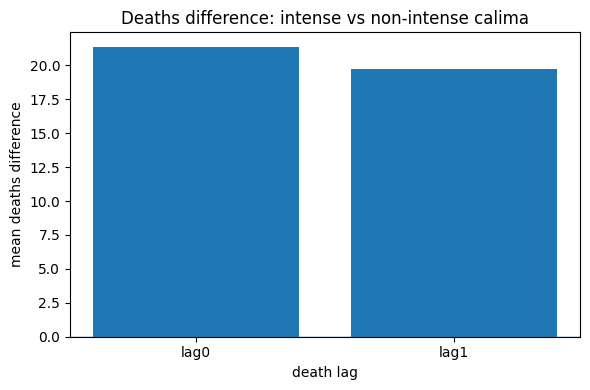

In [42]:
plot_df = intense_vs_nonintense.copy()
plot_df["death_lag"] = plot_df["death_lag"].map({
    "deaths_lag0": "lag0",
    "deaths_lag1": "lag1"
})

plt.figure(figsize=(6,4))
plt.bar(plot_df["death_lag"], plot_df["diff_intense_minus_non_intense"])
plt.axhline(0, linewidth=1)
plt.title("Deaths difference: intense vs non-intense calima")
plt.xlabel("death lag")
plt.ylabel("mean deaths difference")
plt.tight_layout()
plt.show()

En Gran Canaria, las semanas clasificadas como intense por el calima proxy presentan una mortalidad semanal sustancialmente mayor que las semanas no intensas. La diferencia media es de aproximadamente +21 muertes en lag 0 y +20 en lag 1, con evidencia estadística muy fuerte en ambos contrastes descriptivos.

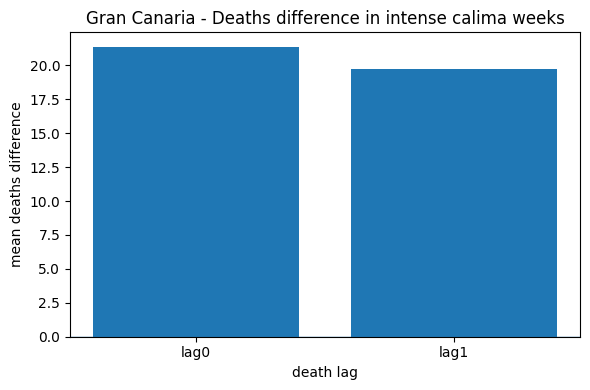

Saved table: C:\dev\projects\heat_mortality_analysis\reports\tables\island\GC\calima_intense_vs_nonintense_deaths_gcan.csv
Saved figure: C:\dev\projects\heat_mortality_analysis\reports\figures\island\GC\calima_intense_vs_nonintense_deaths_diff_gcan.png


In [43]:
# save table + bar chart: intense vs non-intense
OUT_TABLES = ROOT / "reports" / "tables" / "island" / "GC"
OUT_FIGS = ROOT / "reports" / "figures" / "island" / "GC"
OUT_TABLES.mkdir(parents=True, exist_ok=True)
OUT_FIGS.mkdir(parents=True, exist_ok=True)

tbl = intense_vs_nonintense.copy()
tbl["death_lag_label"] = tbl["death_lag"].map({
    "deaths_lag0": "lag0",
    "deaths_lag1": "lag1"
})

csv_fp = OUT_TABLES / "calima_intense_vs_nonintense_deaths_gcan.csv"
fig_fp = OUT_FIGS / "calima_intense_vs_nonintense_deaths_diff_gcan.png"

tbl.to_csv(csv_fp, index=False)

plt.figure(figsize=(6,4))
plt.bar(tbl["death_lag_label"], tbl["diff_intense_minus_non_intense"])
plt.axhline(0, linewidth=1)
plt.title("Gran Canaria - Deaths difference in intense calima weeks")
plt.xlabel("death lag")
plt.ylabel("mean deaths difference")
plt.tight_layout()
plt.savefig(fig_fp, dpi=300, bbox_inches="tight")
plt.show()

print("Saved table:", csv_fp)
print("Saved figure:", fig_fp)

,calima_proxy_level_v2,death_lag,weeks,deaths_mean,deaths_median,deaths_std,death_lag_label
0,no_calima,deaths_lag0,76,138.026,137.0,17.782,lag0
1,possible,deaths_lag0,279,130.789,129.0,19.464,lag0
2,probable,deaths_lag0,79,133.949,130.0,21.368,lag0
3,intense,deaths_lag0,37,154.000,150.0,22.353,lag0
4,no_calima,deaths_lag1,75,136.747,136.0,17.891,lag1
5,possible,deaths_lag1,279,131.806,131.0,19.376,lag1
6,probable,deaths_lag1,79,132.329,129.0,20.636,lag1
7,intense,deaths_lag1,37,152.514,155.0,26.595,lag1


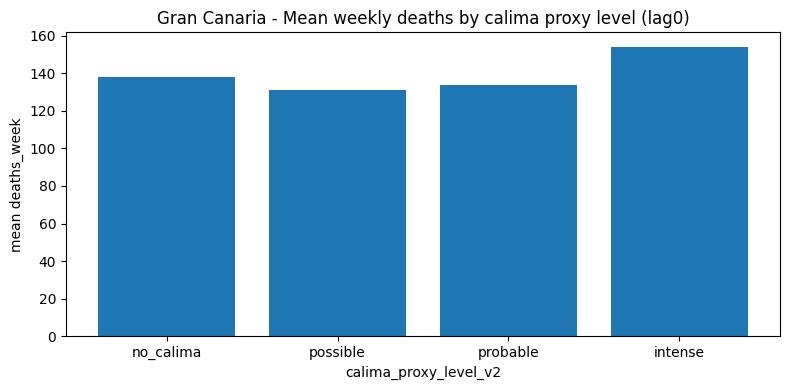

Saved table: C:\dev\projects\heat_mortality_analysis\reports\tables\island\GC\calima_levels_vs_deaths_gcan.csv
Saved figure: C:\dev\projects\heat_mortality_analysis\reports\figures\island\GC\calima_levels_vs_deaths_gcan.png


In [44]:
# segmentación completa por niveles de calima + guardar tabla + gráfico

level_order = ["no_calima", "possible", "probable", "intense"]

cal_seg_df = cal_df.copy().sort_values("week_start").reset_index(drop=True)
cal_seg_df["deaths_lag0"] = cal_seg_df["deaths_week"]
cal_seg_df["deaths_lag1"] = cal_seg_df["deaths_week"].shift(-1)
cal_seg_df["calima_proxy_level_v2"] = pd.Categorical(
    cal_seg_df["calima_proxy_level_v2"],
    categories=level_order,
    ordered=True
)

rows = []
for lag in ["deaths_lag0", "deaths_lag1"]:
    tmp = (
        cal_seg_df.groupby("calima_proxy_level_v2", observed=False)[lag]
        .agg(["count", "mean", "median", "std"])
        .reset_index()
        .rename(columns={
            "count": "weeks",
            "mean": "deaths_mean",
            "median": "deaths_median",
            "std": "deaths_std",
        })
    )
    tmp["death_lag"] = lag
    rows.append(tmp)

level_table = pd.concat(rows, ignore_index=True)[[
    "calima_proxy_level_v2", "death_lag", "weeks", "deaths_mean", "deaths_median", "deaths_std"
]]

level_table["death_lag_label"] = level_table["death_lag"].map({
    "deaths_lag0": "lag0",
    "deaths_lag1": "lag1"
})

for c in ["deaths_mean", "deaths_median", "deaths_std"]:
    level_table[c] = level_table[c].round(3)

csv_fp = OUT_TABLES / "calima_levels_vs_deaths_gcan.csv"
fig_fp = OUT_FIGS / "calima_levels_vs_deaths_gcan.png"

level_table.to_csv(csv_fp, index=False)

display(level_table)

plot_df = level_table[level_table["death_lag_label"] == "lag0"].copy()

plt.figure(figsize=(8,4))
plt.bar(plot_df["calima_proxy_level_v2"].astype(str), plot_df["deaths_mean"])
plt.title("Gran Canaria - Mean weekly deaths by calima proxy level (lag0)")
plt.xlabel("calima_proxy_level_v2")
plt.ylabel("mean deaths_week")
plt.tight_layout()
plt.savefig(fig_fp, dpi=300, bbox_inches="tight")
plt.show()

print("Saved table:", csv_fp)
print("Saved figure:", fig_fp)

In [47]:
combo_df = (
    df[["week_start", "deaths_week", "tmax_c_mean", "temp_c_mean"]]
    .merge(
        cal_df[["week_start", "calima_proxy_score_v2", "calima_proxy_level_v2"]],
        on="week_start",
        how="inner"
    )
    .sort_values("week_start")
    .reset_index(drop=True)
)

print(combo_df.shape)
display(combo_df.head())

(471, 6)


,week_start,deaths_week,tmax_c_mean,temp_c_mean,calima_proxy_score_v2,calima_proxy_level_v2
0,2015-12-28,133.0,22.333333,19.500000,0.5,no_calima
1,2016-01-04,126.0,22.557143,19.400000,0.5,no_calima
2,2016-01-11,127.0,23.871429,20.528571,0.5,no_calima
3,2016-01-18,135.0,22.842857,20.071429,0.5,no_calima
4,2016-01-25,136.0,22.771429,20.100000,2.5,probable


In [48]:
#Flags de calor extremo + calima intensa
p90_tmax = combo_df["tmax_c_mean"].quantile(0.90)
p95_tmax = combo_df["tmax_c_mean"].quantile(0.95)

combo_df["heat_p90"] = (combo_df["tmax_c_mean"] >= p90_tmax).astype(int)
combo_df["heat_p95"] = (combo_df["tmax_c_mean"] >= p95_tmax).astype(int)

combo_df["calima_intense"] = (combo_df["calima_proxy_level_v2"] == "intense").astype(int)

combo_df["deaths_lag0"] = combo_df["deaths_week"]
combo_df["deaths_lag1"] = combo_df["deaths_week"].shift(-1)

print("tmax_c_mean p90:", round(p90_tmax, 2))
print("tmax_c_mean p95:", round(p95_tmax, 2))
print(combo_df[["heat_p90", "heat_p95", "calima_intense"]].sum())

tmax_c_mean p90: 28.19
tmax_c_mean p95: 29.3
heat_p90          48
heat_p95          25
calima_intense    37
dtype: int64


In [49]:
# Solapamiento simple
pd.crosstab(combo_df["heat_p90"], combo_df["calima_intense"], margins=True)

calima_intense,0,1,All
heat_p90,,,
0,388,35,423
1,46,2,48
All,434,37,471


In [50]:
# proporciones
pd.crosstab(
    combo_df["heat_p90"],
    combo_df["calima_intense"],
    normalize="index"
).round(3)

calima_intense,0,1
heat_p90,,
0,0.917,0.083
1,0.958,0.042


In [51]:
# grupos combinados
combo_df["heat_calima_group_p90"] = np.select(
    [
        (combo_df["heat_p90"] == 0) & (combo_df["calima_intense"] == 0),
        (combo_df["heat_p90"] == 1) & (combo_df["calima_intense"] == 0),
        (combo_df["heat_p90"] == 0) & (combo_df["calima_intense"] == 1),
        (combo_df["heat_p90"] == 1) & (combo_df["calima_intense"] == 1),
    ],
    [
        "neither",
        "heat_only",
        "calima_only",
        "heat_and_calima",
    ],
    default="unknown"
)

combo_df["heat_calima_group_p90"].value_counts()

heat_calima_group_p90
neither            388
heat_only           46
calima_only         35
heat_and_calima      2
Name: count, dtype: int64

In [52]:
# Deaths by group
rows = []
for lag in ["deaths_lag0", "deaths_lag1"]:
    tmp = (
        combo_df.groupby("heat_calima_group_p90", observed=False)[lag]
        .agg(["count", "mean", "median", "std"])
        .reset_index()
        .rename(columns={
            "count": "weeks",
            "mean": "deaths_mean",
            "median": "deaths_median",
            "std": "deaths_std",
        })
    )
    tmp["death_lag"] = lag
    rows.append(tmp)

group_table_p90 = pd.concat(rows, ignore_index=True)
group_table_p90

,heat_calima_group_p90,weeks,deaths_mean,deaths_median,deaths_std,death_lag
0,calima_only,35,155.400000,150.0,22.055011,deaths_lag0
1,heat_and_calima,2,129.500000,129.5,13.435029,deaths_lag0
2,heat_only,46,130.934783,131.0,23.063586,deaths_lag0
3,neither,388,132.832474,131.5,19.280341,deaths_lag0
4,calima_only,35,152.171429,155.0,24.426945,deaths_lag1
5,heat_and_calima,2,158.500000,158.5,71.417785,deaths_lag1
6,heat_only,46,129.065217,130.5,18.870791,deaths_lag1
7,neither,387,133.196382,132.0,19.448689,deaths_lag1


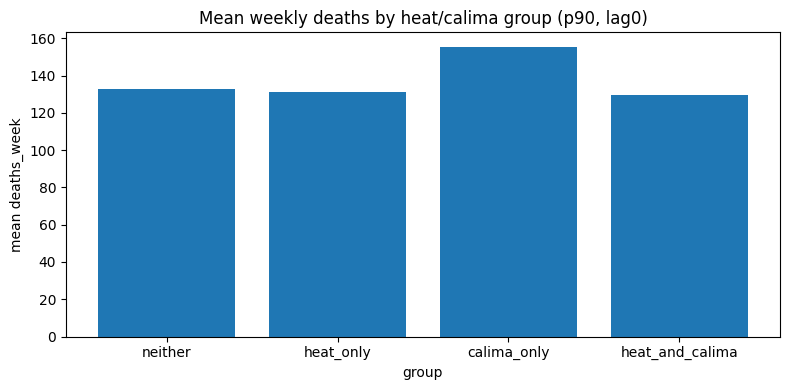

In [53]:
plot_df = group_table_p90[group_table_p90["death_lag"] == "deaths_lag0"].copy()

order = ["neither", "heat_only", "calima_only", "heat_and_calima"]
plot_df["heat_calima_group_p90"] = pd.Categorical(
    plot_df["heat_calima_group_p90"],
    categories=order,
    ordered=True
)
plot_df = plot_df.sort_values("heat_calima_group_p90")

plt.figure(figsize=(8,4))
plt.bar(plot_df["heat_calima_group_p90"].astype(str), plot_df["deaths_mean"])
plt.title("Mean weekly deaths by heat/calima group (p90, lag0)")
plt.xlabel("group")
plt.ylabel("mean deaths_week")
plt.tight_layout()
plt.show()

La combinación de calor extremo y calima intensa muestra una asociación descriptiva con la mortalidad semanal, pero esta relación puede estar influida por estacionalidad, por patrones temporales compartidos entre exposiciones, y por la concurrencia de otras condiciones atmosféricas relacionadas.
Cuando aparece calima intensa, incluso sin calor extremo p90, la mortalidad media semanal es bastante más alta
En la segmentación conjunta calor–calima para Gran Canaria, la señal más clara aparece en las semanas calima_only, que muestran mortalidad media más alta que las semanas neither tanto en lag 0 como en lag 1. En cambio, el grupo heat_and_calima contiene solo 2 semanas, por lo que no permite una interpretación robusta sobre interacción entre calor extremo y calima intensa.


### ¿Las semanas con más señal de calima tienden a ser más cálidas?
### ¿La mortalidad sube sobre todo cuando la calima es intensa, o ya sube desde niveles probable?

In [56]:
#tabla combinada y anomalías térmicas
# --- combine master temperature + calima proxy ---
cal_temp_df = (
    df[["week_start", "temp_c_mean", "tmax_c_mean", "tmin_c_mean"]]
    .merge(
        cal_df[["week_start", "calima_proxy_score_v2", "calima_proxy_level_v2"]],
        on="week_start",
        how="inner"
    )
    .sort_values("week_start")
    .reset_index(drop=True)
)

cal_temp_df["weekofyear"] = cal_temp_df["week_start"].dt.isocalendar().week.astype(int)

# climatology + anomaly for mean / max / min temperature
for var in ["temp_c_mean", "tmax_c_mean", "tmin_c_mean"]:
    clim = (
        cal_temp_df.groupby("weekofyear", observed=False)[var]
        .mean()
        .rename(f"{var}_clim")
        .reset_index()
    )
    cal_temp_df = cal_temp_df.merge(clim, on="weekofyear", how="left")
    cal_temp_df[f"{var}_anom"] = cal_temp_df[var] - cal_temp_df[f"{var}_clim"]

level_order = ["no_calima", "possible", "probable", "intense"]
cal_temp_df["calima_proxy_level_v2"] = pd.Categorical(
    cal_temp_df["calima_proxy_level_v2"],
    categories=level_order,
    ordered=True
)

print(cal_temp_df.shape)
display(cal_temp_df.head())

(471, 13)


,week_start,temp_c_mean,tmax_c_mean,tmin_c_mean,calima_proxy_score_v2,calima_proxy_level_v2,weekofyear,temp_c_mean_clim,temp_c_mean_anom,tmax_c_mean_clim,tmax_c_mean_anom,tmin_c_mean_clim,tmin_c_mean_anom
0,2015-12-28,19.500000,22.333333,16.666667,0.5,no_calima,53,18.850000,0.650000,21.588095,0.745238,16.111905,0.554762
1,2016-01-04,19.400000,22.557143,16.242857,0.5,no_calima,1,18.950476,0.449524,21.950476,0.606667,15.947619,0.295238
2,2016-01-11,20.528571,23.871429,17.214286,0.5,no_calima,2,18.786772,1.741799,21.650529,2.220899,15.940212,1.274074
3,2016-01-18,20.071429,22.842857,17.285714,0.5,no_calima,3,18.661640,1.409788,21.604233,1.238624,15.721958,1.563757
4,2016-01-25,20.100000,22.771429,17.400000,2.5,probable,4,18.395238,1.704762,21.284127,1.487302,15.490476,1.909524


In [57]:
temp_by_calima_level = (
    cal_temp_df.groupby("calima_proxy_level_v2", observed=False)
    .agg(
        weeks=("week_start", "size"),
        temp_mean=("temp_c_mean", "mean"),
        temp_anom_mean=("temp_c_mean_anom", "mean"),
        tmax_mean=("tmax_c_mean", "mean"),
        tmax_anom_mean=("tmax_c_mean_anom", "mean"),
        tmin_mean=("tmin_c_mean", "mean"),
        tmin_anom_mean=("tmin_c_mean_anom", "mean"),
    )
    .reset_index()
)
csv_fp = OUT_TABLES / "temp_vs_calima_gcan.csv"
temp_by_calima_level.to_csv(csv_fp, index=False)
print("Saved table:", csv_fp)
temp_by_calima_level = temp_by_calima_level.round(3)
temp_by_calima_level

Saved table: C:\dev\projects\heat_mortality_analysis\reports\tables\island\GC\temp_vs_calima_gcan.csv


,calima_proxy_level_v2,weeks,temp_mean,temp_anom_mean,tmax_mean,tmax_anom_mean,tmin_mean,tmin_anom_mean
0,no_calima,76,21.636,0.190,24.736,0.223,18.537,0.157
1,possible,279,22.025,-0.232,25.026,-0.295,19.025,-0.168
2,probable,79,21.963,0.460,25.239,0.597,18.685,0.320
3,intense,37,19.859,0.383,23.045,0.499,16.673,0.268


In [62]:
# Proporcion de semanas con anomalia positiva por el nivel de calima
cal_temp_df["temp_anom_pos"] = (cal_temp_df["temp_c_mean_anom"] > 0).astype(int)
cal_temp_df["tmax_anom_pos"] = (cal_temp_df["tmax_c_mean_anom"] > 0).astype(int)
cal_temp_df["tmin_anom_pos"] = (cal_temp_df["tmin_c_mean_anom"] > 0).astype(int)

anom_positive_by_level = (
    cal_temp_df.groupby("calima_proxy_level_v2", observed=False)
    .agg(
        weeks=("week_start", "size"),
        temp_anom_pos_n=("temp_anom_pos", "sum"),
        temp_anom_pos_pct=("temp_anom_pos", "mean"),
        tmax_anom_pos_n=("tmax_anom_pos", "sum"),
        tmax_anom_pos_pct=("tmax_anom_pos", "mean"),
        tmin_anom_pos_n=("tmin_anom_pos", "sum"),
        tmin_anom_pos_pct=("tmin_anom_pos", "mean"),
    )
    .reset_index()
)

for c in ["temp_anom_pos_pct", "tmax_anom_pos_pct", "tmin_anom_pos_pct"]:
    anom_positive_by_level[c] = (anom_positive_by_level[c] * 100).round(1)
csv_fp = OUT_TABLES / "anom_positive_by_level_gcan.csv"
anom_positive_by_level.to_csv(csv_fp, index=False)
print("Saved table:", csv_fp)
anom_positive_by_level

Saved table: C:\dev\projects\heat_mortality_analysis\reports\tables\island\GC\anom_positive_by_level_gcan.csv


,calima_proxy_level_v2,weeks,temp_anom_pos_n,temp_anom_pos_pct,tmax_anom_pos_n,tmax_anom_pos_pct,tmin_anom_pos_n,tmin_anom_pos_pct
0,no_calima,76,43,56.6,42,55.3,43,56.6
1,possible,279,106,38.0,96,34.4,114,40.9
2,probable,79,43,54.4,44,55.7,42,53.2
3,intense,37,20,54.1,22,59.5,18,48.6


In [59]:
#Correlacion entre score de calima y anomalia termica
cal_temp_df[[
    "calima_proxy_score_v2",
    "temp_c_mean_anom",
    "tmax_c_mean_anom",
    "tmin_c_mean_anom"
]].corr(numeric_only=True)

,calima_proxy_score_v2,temp_c_mean_anom,tmax_c_mean_anom,tmin_c_mean_anom
calima_proxy_score_v2,1.000000,0.146900,0.145918,0.131745
temp_c_mean_anom,0.146900,1.000000,0.964864,0.935560
tmax_c_mean_anom,0.145918,0.964864,1.000000,0.810130
tmin_c_mean_anom,0.131745,0.935560,0.810130,1.000000


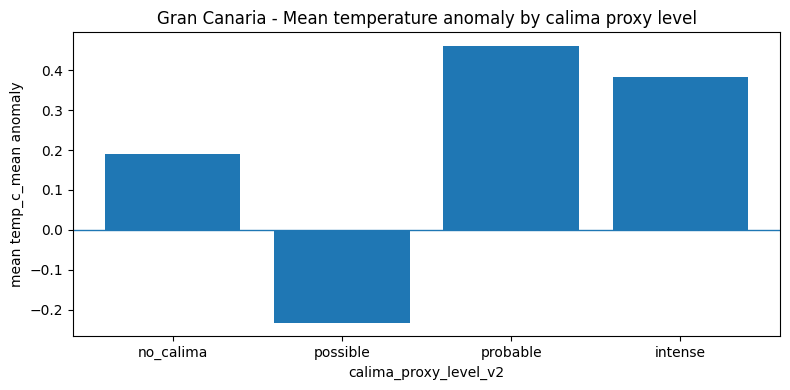

Saved figure: C:\dev\projects\heat_mortality_analysis\reports\figures\island\GC\temp_by_calima_level.png


In [60]:
fig_fp = OUT_FIGS / "temp_by_calima_level.png"
plot_df = temp_by_calima_level.copy()

plt.figure(figsize=(8,4))
plt.bar(plot_df["calima_proxy_level_v2"].astype(str), plot_df["temp_anom_mean"])
plt.axhline(0, linewidth=1)
plt.title("Gran Canaria - Mean temperature anomaly by calima proxy level")
plt.xlabel("calima_proxy_level_v2")
plt.ylabel("mean temp_c_mean anomaly")
plt.tight_layout()
plt.savefig(fig_fp, dpi=300, bbox_inches="tight")
plt.show()
print("Saved figure:", fig_fp)

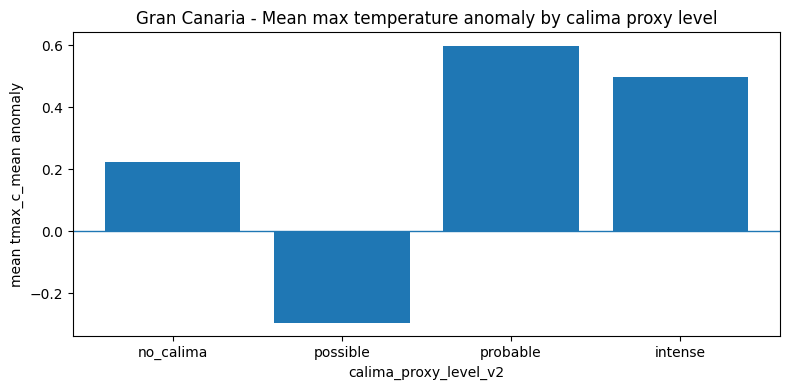

In [61]:
# Maximo semanal
plt.figure(figsize=(8,4))
plt.bar(plot_df["calima_proxy_level_v2"].astype(str), plot_df["tmax_anom_mean"])
plt.axhline(0, linewidth=1)
plt.title("Gran Canaria - Mean max temperature anomaly by calima proxy level")
plt.xlabel("calima_proxy_level_v2")
plt.ylabel("mean tmax_c_mean anomaly")
plt.tight_layout()
plt.show()

En **Gran Canaria**, los episodios de calima definidos por el proxy **tienden** a coincidir con semanas térmicamente algo más cálidas de lo normal, especialmente en **temperatura máxima**, pero esa coincidencia es **modesta**, no dominante. Los niveles `probable` e `intense` muestran anomalías medias positivas, pero la proporción de semanas con anomalía térmica positiva se sitúa solo ligeramente por encima del 50%, y la correlación entre el score de calima y las anomalías térmicas es débil. En términos prácticos, esto sugiere que **calima y calor anómalo pueden coincidir**, pero **no forman un mismo fenómeno ni una combinación sistemática fuerte** en la serie semanal.

La lectura más importante del bloque es que **la señal de calima sobre mortalidad parece más autónoma que dependiente del calor anómalo**. Eso encaja con los resultados previos: la temperatura, por sí sola, daba una señal débil o dominada por estacionalidad, mientras que la **calima intensa** sí mostraba una asociación mucho más clara con semanas de mayor mortalidad. Por tanto, para el EDA de Gran Canaria, conviene tratar **calima** y **calor** como exposiciones relacionadas pero distintas, evitando asumir que los episodios de calima intensa son, en su mayoría, semanas de calor anómalo.


## Gran Canaria: narrative EDA summary

The Gran Canaria weekly master dataset covers **471 weeks** from **2015-12-28 to 2024-12-30**, with a clean weekly structure, no duplicate `week_start` values, and complete 7-day continuity across the series. The integrated dataset combines mortality, weather, visibility, air quality, CAP alerts, and a weekly calima proxy. From a data-quality perspective, the core pipeline was successfully rebuilt and validated. Mortality, weather, visibility, and air-quality series cover almost the full analysis window, while **CAP is only available from 2018-06-18 onward** and **Heliyon/DAI only up to March 2022**, producing structural missingness rather than merge errors.

The first important result is that **absolute temperature** shows a moderate negative association with weekly mortality (`temp_c_mean r = -0.393`, `tmax_c_mean r = -0.365`, `tmin_c_mean r = -0.412`). However, this pattern weakens almost completely when temperature is expressed as a **weekly anomaly** relative to its seasonal baseline (`temp_c_mean_anom r = 0.064`, `tmax_c_mean_anom r = 0.088`, `tmin_c_mean_anom r = 0.026`). This strongly suggests that the crude temperature–mortality relationship is driven mainly by **seasonality**, rather than by a clear week-to-week thermal effect. Consistent with this, extreme-heat weeks defined using **p90/p95 thresholds** for temperature did not show a robust excess-mortality signal at either **lag 0** or **lag 1**; mean differences were small or inconsistent in sign, and Welch tests were not statistically significant.

By contrast, the **calima block** produced a much more informative signal. The `calima_proxy_score_v2` showed a positive correlation with weekly mortality (`r = 0.237`), comparable to `PM10` (`r = 0.252`) and somewhat lower than `pressure_hpa_mean` (`r = 0.284`). The level-based segmentation did not show a perfectly monotonic gradient across all categories, but the **`intense`** weeks stood out clearly. Their mean weekly mortality reached **154.0 deaths/week**, compared with **132.6** in non-intense weeks at **lag 0**, and **152.5** versus **132.8** at **lag 1**. This corresponds to differences of roughly **+21** and **+20 deaths/week**, respectively, with very strong statistical evidence in both descriptive contrasts. In practical terms, the proxy appears more useful as a marker of **intense calima episodes** than as a perfectly linear severity scale.

A further comparison between **calima severity** and **thermal anomalies** suggests only a **moderate overlap**. Weeks classified as `probable` or `intense` tended to have positive temperature anomalies, especially for `tmax`, but the effect was not dominant: the share of weeks with positive anomalies was only slightly above **50%**, and the correlation between `calima_proxy_score_v2` and temperature anomalies was weak (around **0.13–0.15**). This indicates that calima and unusually warm weeks can coincide, but they do not behave as a single combined phenomenon in the weekly series.

Overall, the Gran Canaria EDA suggests that the most consistent environmental signal linked to weekly mortality does **not** come from temperature alone, but from **intense calima episodes**, likely reflecting a combination of **elevated PM10, dry conditions, high pressure, and reduced visibility**. The main limitations are the **partial coverage of CAP and Heliyon**, the possibility of **seasonal and temporal confounding**, and the fact that all findings remain **descriptive rather than causal** at this stage.

EDA Gran Canaria closed.
Core weekly dataset validated and exploratory narrative completed.
Main signal: intense calima shows a clearer association with weekly mortality than temperature alone.
Known limitations: partial CAP coverage from 2018 onward and Heliyon/DAI coverage only up to March 2022.